# **Advanced Machine Learning**
# **D1.2 – Project Submission**

**C1 - DEPENDENCIAS + IMPORTS**

In [24]:
# Instalación segura de dependencias necesarias
import sys
import subprocess

# Lista de paquetes requeridos para el proyecto
packages = [
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'imbalanced-learn',
    'openpyxl',
    'xgboost',
    'optuna'
]

# Comprobamos si cada paquete está instalado, si no lo instalamos
for pkg in packages:
    try:
        if pkg == 'scikit-learn':
            __import__('sklearn')  # nombre interno distinto
        elif pkg == 'imbalanced-learn':
            __import__('imblearn')
        else:
            __import__(pkg)
        print(f"✓ {pkg} ya está instalado")
    except ImportError:
        print(f'Instalando {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f"✓ {pkg} instalado correctamente")

# Importación de librerías principales para análisis y modelado
try:
    import pandas as pd  # manipulación de datos
    import numpy as np   # operaciones numéricas
    import matplotlib.pyplot as plt  # visualización básica
    import seaborn as sns  # visualización avanzada

    # Preprocesamiento
    from sklearn.preprocessing import StandardScaler, LabelEncoder

    # División de datos
    from sklearn.model_selection import train_test_split

    # Modelo base
    from sklearn.ensemble import RandomForestClassifier

    # Pipeline (para integrar pasos de forma segura)
    from imblearn.pipeline import Pipeline

    # Métricas de evaluación
    from sklearn.metrics import classification_report, f1_score, confusion_matrix

    # Técnica de balanceo
    from imblearn.over_sampling import SMOTE

    print("\n✓ Todas las librerías importadas correctamente")

except Exception as e:
    print('Error en importaciones:', e)
    raise

✓ pandas ya está instalado
✓ numpy ya está instalado
✓ matplotlib ya está instalado
✓ seaborn ya está instalado
✓ scikit-learn ya está instalado
✓ imbalanced-learn ya está instalado
✓ openpyxl ya está instalado
✓ xgboost ya está instalado
✓ optuna ya está instalado

✓ Todas las librerías importadas correctamente


## **1. DATA PREPROCESSING**

**C2 — Preprocessing completo**

In [25]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder


# 1. Load the dataset
# Note: Make sure the file name matches the path in your environment
df = pd.read_excel("Dry_Bean_Dataset.xlsx")


# Visualize if there are missing values initially
print("Análisis de datos faltantes por columna:")
print(df.isnull().sum())


# 2. Separate features (X) and target variable (y)
X = df.drop(columns=['Class']) # features
y = df['Class'] # target


# 3. Encoding the categorical variable (Target)
# We use LabelEncoder because 'Class' is the multiclass target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 4. Split dataset into training and test sets (CRITICAL to avoid Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


# 5. Missing data imputation strategy
# Although the Dry Beans dataset usually has no missing values, it is good practice to include an imputer
# We use the median because it is less sensitive to outliers in geometric features
imputer = SimpleImputer(strategy='median')


# IMPORTANT: Apply fit_transform ONLY on the training set
X_train_imputed = imputer.fit_transform(X_train)

# For the test set, only apply transform (using medians from train)
X_test_imputed = imputer.transform(X_test)


# 6. Standardization / Normalization
# We use StandardScaler so that variables have mean 0 and standard deviation 1
# This is important because 'Area' is in tens of thousands and 'ShapeFactors' are very small decimals
scaler = StandardScaler()

# Again, fit_transform on train and only transform on test
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Convert back to DataFrames (optional, for better visualization or later use)
feature_names = X.columns
X_train_final = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_final = pd.DataFrame(X_test_scaled, columns=feature_names)



print("\nPreprocesamiento completado con éxito.")
print(f"Dimensiones de X_train_final: {X_train_final.shape}")
print(f"Dimensiones de X_test_final: {X_test_final.shape}")

Análisis de datos faltantes por columna:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Preprocesamiento completado con éxito.
Dimensiones de X_train_final: (10888, 16)
Dimensiones de X_test_final: (2723, 16)


## **2. Imbalance Analysis and Mitigation**

**C3 - Imbalance**

In [26]:
# Import balancing libraries
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Show original class distribution in training set
print(f"Original distribution in y_train: {Counter(y_train)}")

# Random undersampling: reduce all classes to minority size
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_final, y_train)
print(f"After undersampling: {Counter(y_train_rus)}")

# Random oversampling: duplicate minority classes to match majority
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train_final, y_train)
print(f"After oversampling: {Counter(y_train_ros)}")

# SMOTE: generate synthetic samples for minority classes
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_final, y_train)
print(f"After SMOTE: {Counter(y_train_smote)}")

# Keep test set unchanged for final evaluation

Original distribution in y_train: Counter({np.int64(3): 2837, np.int64(6): 2109, np.int64(5): 1621, np.int64(4): 1542, np.int64(2): 1304, np.int64(0): 1057, np.int64(1): 418})
After undersampling: Counter({np.int64(0): 418, np.int64(1): 418, np.int64(2): 418, np.int64(3): 418, np.int64(4): 418, np.int64(5): 418, np.int64(6): 418})
After oversampling: Counter({np.int64(5): 2837, np.int64(4): 2837, np.int64(2): 2837, np.int64(6): 2837, np.int64(3): 2837, np.int64(0): 2837, np.int64(1): 2837})
After SMOTE: Counter({np.int64(5): 2837, np.int64(4): 2837, np.int64(2): 2837, np.int64(6): 2837, np.int64(3): 2837, np.int64(0): 2837, np.int64(1): 2837})


**C4 — Export**

In [27]:
# Combine X and y to save as CSV files
# 1. Balanced training set (SMOTE) - main dataset
train_smote_df = pd.DataFrame(X_train_smote, columns=feature_names)
train_smote_df['Class'] = y_train_smote
train_smote_df.to_csv("train_data_SMOTE.csv", index=False)

# 2. Original training set (imbalanced) - for comparison
train_original_df = X_train_final.copy()
train_original_df['Class'] = y_train
train_original_df.to_csv("train_data_IMBALANCED.csv", index=False)

# 3. Test set - kept for final evaluation
test_df = X_test_final.copy()
test_df['Class'] = y_test
test_df.to_csv("test_data_FINAL.csv", index=False)

print("Files exported successfully.")

Files exported successfully.



**C5 — Info dataset**

In [28]:
# Final check of dataset status
print("✓ Dataset completamente procesado y listo para modelado")

# After SMOTE
print(f"  - Datos de entrenamiento después de SMOTE: {X_train_smote.shape}")

# Balanced classes
print(f"  - Clases balanceadas: {np.unique(y_train_smote)}")

✓ Dataset completamente procesado y listo para modelado
  - Datos de entrenamiento después de SMOTE: (19859, 16)
  - Clases balanceadas: [0 1 2 3 4 5 6]


**C6 — EDA**


--- 3. ANÁLISIS EXPLORATORIO DE DATOS ---


C:\Users\alvaro.franco\AppData\Local\Temp\ipykernel_25016\2748424731.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='Set2')
C:\Users\alvaro.franco\AppData\Local\Temp\ipykernel_25016\2748424731.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_smote, palette='Set2')


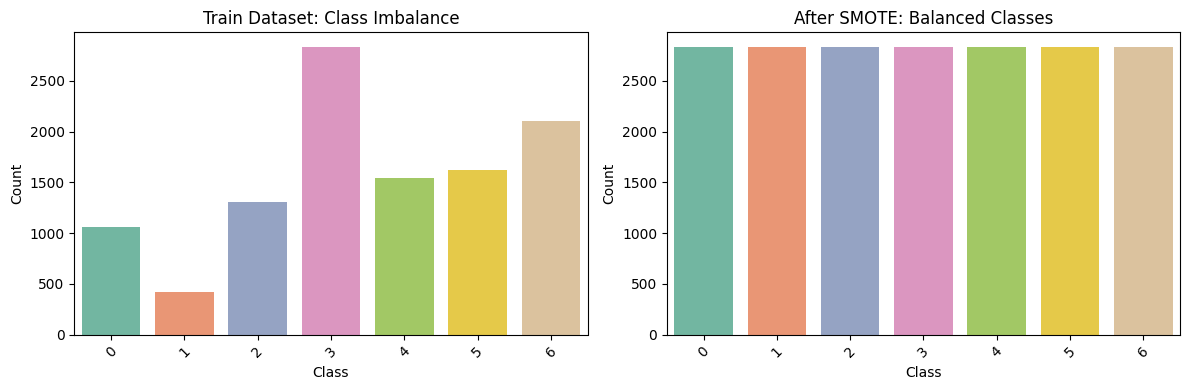


Distribuciones de características (primeras 4):


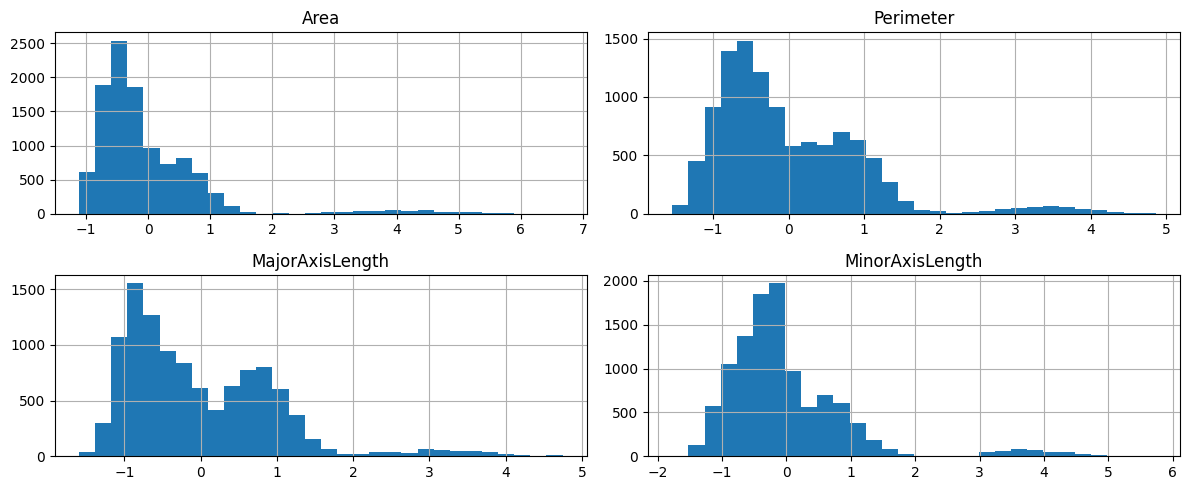


Matriz de correlación:


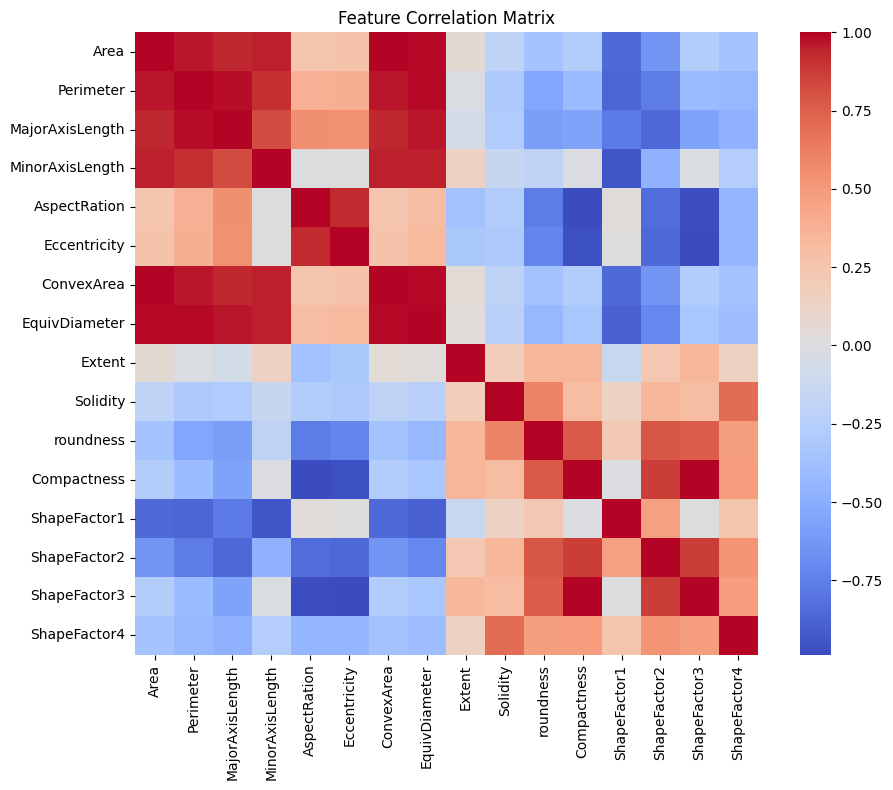


✓ Análisis exploratorio completado


In [29]:
# Exploratory analysis
print("\n--- 3. ANÁLISIS EXPLORATORIO DE DATOS ---")

plt.figure(figsize=(12, 4))

# Original class distribution in train set
plt.subplot(1, 2, 1)
sns.countplot(x=y_train, palette='Set2')
plt.title('Train Dataset: Class Imbalance')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Class distribution after SMOTE
plt.subplot(1, 2, 2)
sns.countplot(x=y_train_smote, palette='Set2')
plt.title('After SMOTE: Balanced Classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Feature distributions
print("\nDistribuciones de características (primeras 4):")

X_train_final.iloc[:, :4].hist(figsize=(12, 5), bins=30)
plt.tight_layout()
plt.show()

# Feature correlation
print("\nMatriz de correlación:")

plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), cmap='coolwarm', square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("\n✓ Análisis exploratorio completado")

## **3. Model Comparison and Hyperparameter Tuning**

**C8 - BASELINE**

In [30]:
# Baseline models without imbalance handling
# Objective: establish a reference performance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

print("\n--- BASELINE MODELS (NO IMBALANCE HANDLING) ---")

# Logistic Regression (simple linear model)
lr = LogisticRegression(max_iter=1000, random_state=42)

# Train on processed data
lr.fit(X_train_final, y_train)

# Predict on test set
y_pred_lr = lr.predict(X_test_final)

print("\n=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print("Macro F1:", f1_score(y_test, y_pred_lr, average="macro"))

# Decision Tree (base model for ensembles)
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_final, y_train)
y_pred_dt = dt.predict(X_test_final)

print("\n=== Decision Tree ===")
print(classification_report(y_test, y_pred_dt))
print("Macro F1:", f1_score(y_test, y_pred_dt, average="macro"))


--- BASELINE MODELS (NO IMBALANCE HANDLING) ---

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       265
           1       1.00      1.00      1.00       104
           2       0.93      0.94      0.94       326
           3       0.92      0.91      0.92       709
           4       0.96      0.95      0.96       386
           5       0.93      0.95      0.94       406
           6       0.85      0.88      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723

Macro F1: 0.9335383155807854

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.88      0.91      0.89       265
           1       1.00      1.00      1.00       104
           2       0.92      0.91      0.92       326
           3       0.88      0.90      0.89       709
  

### **MODEL 1. RANDOM FOREST**

**C9 — Modelo A**

In [31]:
# Random Forest with class_weight
print("\n--- MODELO A: RandomForest (class_weight) ---")

# Automatically adjust weights for imbalanced classes
rf_a = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# Train model on processed data (no SMOTE)
rf_a.fit(X_train_final, y_train)

# Predict on test set
y_pred_a = rf_a.predict(X_test_final)

# Evaluate performance
print(classification_report(y_test, y_pred_a))
print("Macro F1:", f1_score(y_test, y_pred_a, average="macro"))

# Confusion matrix
cm_a = confusion_matrix(y_test, y_pred_a)
print(cm_a)

print("\n✓ Modelo A completado")


--- MODELO A: RandomForest (class_weight) ---
              precision    recall  f1-score   support

           0       0.94      0.89      0.91       265
           1       1.00      1.00      1.00       104
           2       0.94      0.94      0.94       326
           3       0.91      0.92      0.92       709
           4       0.97      0.95      0.96       386
           5       0.94      0.96      0.95       406
           6       0.86      0.85      0.85       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723

Macro F1: 0.9326187597475176
[[236   0  17   0   1   2   9]
 [  0 104   0   0   0   0   0]
 [ 10   0 305   0   5   2   4]
 [  0   0   0 655   0  10  44]
 [  1   0   4   4 368   0   9]
 [  1   0   0   6   0 389  10]
 [  4   0   0  55   7  11 450]]

✓ Modelo A completado


In [32]:
# Compare baseline models vs Random Forest
# Objective: compare simple models with ensemble

print("\n--- COMPARACIÓN DE MODELOS ---")

# Compute main metrics
f1_lr = f1_score(y_test, y_pred_lr, average="macro")
f1_dt = f1_score(y_test, y_pred_dt, average="macro")
f1_rf = f1_score(y_test, y_pred_a, average="macro")  # Random Forest

# Show results
print("\nMacro F1 Scores:")
print(f"Logistic Regression: {f1_lr:.4f}")
print(f"Decision Tree:       {f1_dt:.4f}")
print(f"Random Forest:       {f1_rf:.4f}")

# Select best model
best_model = max(
    [("Logistic Regression", f1_lr),
    ("Decision Tree", f1_dt),
    ("Random Forest", f1_rf)],
    key=lambda x: x[1]
)

print(f"\nMejor modelo hasta ahora: {best_model[0]} ({best_model[1]:.4f})")


--- COMPARACIÓN DE MODELOS ---

Macro F1 Scores:
Logistic Regression: 0.9335
Decision Tree:       0.9081
Random Forest:       0.9326

Mejor modelo hasta ahora: Logistic Regression (0.9335)


**INSIGHT**: “Interestingly, Logistic Regression slightly outperformed Random Forest, suggesting that the dataset is well-structured and linearly separable to a large extent.”

**C10 — Modelo B + comparación**

In [33]:
# Model B: Pipeline with SMOTE

print("\n--- MODELO B: SMOTE + RandomForest ---")

# SMOTE inside pipeline to avoid data leakage
smote_pipe = SMOTE(random_state=42)

rf_b = RandomForestClassifier(  # class_weight removed to isolate SMOTE effect
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

pipe_b = Pipeline([
    ("smote", smote_pipe),
    ("rf", rf_b)
])

# Train on processed data
pipe_b.fit(X_train_final, y_train)

# Predict on test set
y_pred_b = pipe_b.predict(X_test_final)

# Evaluate performance
print(classification_report(y_test, y_pred_b))
print("Macro F1:", f1_score(y_test, y_pred_b, average="macro"))

# Compare Method A vs Method B
f1_a = f1_score(y_test, y_pred_a, average="macro")
f1_b = f1_score(y_test, y_pred_b, average="macro")

print(f"\nMethod A: {f1_a:.4f}")
print(f"Method B: {f1_b:.4f}")
print(f"Best method: {'A (class_weight)' if f1_a > f1_b else 'B (SMOTE)' if f1_b > f1_a else 'Tie'}")


--- MODELO B: SMOTE + RandomForest ---
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       265
           1       1.00      1.00      1.00       104
           2       0.94      0.94      0.94       326
           3       0.92      0.91      0.91       709
           4       0.96      0.95      0.96       386
           5       0.94      0.96      0.95       406
           6       0.86      0.86      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723

Macro F1: 0.9325596766874037

Method A: 0.9326
Method B: 0.9326
Best method: A (class_weight)


**INSIGHT:** The application of SMOTE did not lead to any significant improvement in model performance. 
This is likely due to the fact that the dataset, although imbalanced, is highly separable based on its features. 
As a result, the model is already able to correctly classify minority classes without the need for synthetic data generation.

**C10 - ENSEMBLE METHODS**

In [34]:
# Ensemble models without tuning

from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier

print("\n--- ENSEMBLE MODELS (BASE) ---")

# Define models
models = {
    "Random Forest": rf_a,  # already trained
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    if name != "Random Forest":
        # Train on processed data
        model.fit(X_train_final, y_train)

        # Predict on test set
        y_pred = model.predict(X_test_final)
    else:
        # Reuse predictions from trained Random Forest
        y_pred = y_pred_a

    # Evaluate using Macro F1
    f1 = f1_score(y_test, y_pred, average="macro")
    results[name] = f1

    print(f"{name} - Macro F1: {f1:.4f}")

# Show summary
print("\n--- SUMMARY ---")
for name, score in results.items():
    print(f"{name}: {score:.4f}")


--- ENSEMBLE MODELS (BASE) ---

Training Random Forest...
Random Forest - Macro F1: 0.9326

Training Gradient Boosting...
Gradient Boosting - Macro F1: 0.9343

Training AdaBoost...
AdaBoost - Macro F1: 0.6780

Training Extra Trees...
Extra Trees - Macro F1: 0.9283

--- SUMMARY ---
Random Forest: 0.9326
Gradient Boosting: 0.9343
AdaBoost: 0.6780
Extra Trees: 0.9283


XGBoost is an advanced boosting algorithm that extends traditional Gradient Boosting by incorporating regularization techniques and more efficient optimization strategies. 

Due to these improvements, it often achieves competitive or superior performance, making it a relevant model to include in our comparison.

In [35]:
# XGBoost model

from xgboost import XGBClassifier

print("\n--- XGBoost ---")

# Define model
xgb = XGBClassifier(
    n_estimators=200,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_jobs=-1
)

# Train on processed data
xgb.fit(X_train_final, y_train)

# Predict on test set
y_pred_xgb = xgb.predict(X_test_final)

# Evaluate performance
f1_xgb = f1_score(y_test, y_pred_xgb, average="macro")

print("Macro F1:", f1_xgb)


--- XGBoost ---


c:\Users\alvaro.franco\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:49:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Macro F1: 0.9347338603971646


### Model Ranking and Selection

After evaluating several baseline and ensemble models, we rank them based on their Macro F1 score, which is an appropriate metric for imbalanced classification problems.

The goal of this step is to identify the most promising models for further optimization using hyperparameter tuning techniques.

Rather than tuning all models, we focus only on the top-performing ones, as this allows us to efficiently allocate computational resources and avoid unnecessary complexity.

The selected models will be optimized using Optuna in the next section.

In [36]:
# MODEL RANKING AND SELECTION
# Objective:
# Rank all evaluated models and select the most promising ones
# for further hyperparameter tuning (Optuna)


print("\n--- MODEL RANKING ---")


# Save results in a dictionary
model_results = {
    "Logistic Regression": f1_lr,
    "Decision Tree": f1_dt,
    "Random Forest": f1_a,
    "Gradient Boosting": results["Gradient Boosting"],
    "Extra Trees": results["Extra Trees"],
    "AdaBoost": results["AdaBoost"],
    "XGBoost": f1_xgb
}

# Order models by performance
sorted_models = sorted(model_results.items(), key=lambda x: x[1], reverse=True)

# Ranking
for i, (name, score) in enumerate(sorted_models, 1):
    print(f"{i}. {name}: {score:.4f}")
    
# Best 2 models for tuning
top_models = sorted_models[:2]

print("\n--- SELECTED MODELS FOR TUNING ---")
for name, score in top_models:
    print(f"{name}: {score:.4f}")
    
print("\nNOTE:")
print("Differences between top models are small, suggesting that the dataset is relatively easy to classify.")


--- MODEL RANKING ---
1. XGBoost: 0.9347
2. Gradient Boosting: 0.9343
3. Logistic Regression: 0.9335
4. Random Forest: 0.9326
5. Extra Trees: 0.9283
6. Decision Tree: 0.9081
7. AdaBoost: 0.6780

--- SELECTED MODELS FOR TUNING ---
XGBoost: 0.9347
Gradient Boosting: 0.9343

NOTE:
Differences between top models are small, suggesting that the dataset is relatively easy to classify.


**INSIGHT:** Only the top-performing models (XGBoost and Gradient Boosting) were selected for hyperparameter tuning. 

This decision allows us to focus computational resources on the most promising approaches, while avoiding unnecessary optimization of models that already showed inferior performance.

### Hyperparameter Tuning with Optuna (XGBoost)

In this section, we apply hyperparameter optimization using Optuna to improve the performance of the XGBoost model.

Optuna is an efficient optimization framework that explores the hyperparameter space using intelligent sampling strategies and prunes unpromising trials to reduce computational cost.

We use cross-validation to ensure robust performance estimation and optimize the Macro F1 score, which is appropriate for imbalanced classification problems.

In [ ]:
# Optuna tuning for XGBoost
import optuna
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier

print("\n--- OPTUNA: XGBOOST---")

def objective(trial):

    # Define search space
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "random_state": 42,
        "n_jobs": -1,
        "eval_metric": "mlogloss"
    }

    # Create model with trial params
    model = XGBClassifier(**params)

    # Cross-validation
    scores = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        cv=3,
        scoring="f1_macro",
        n_jobs=-1
    )

    # Return average score
    return scores.mean()

# Use pruner to stop bad trials early
pruner = optuna.pruners.MedianPruner()

# Create study
study = optuna.create_study(direction="maximize", pruner=pruner)

# Run optimization
study.optimize(objective, n_trials=25)

# Show best results
print("\nBest parameters:")
print(study.best_params)

print("\nBest CV Macro F1:")
print(study.best_value)

[I 2026-03-22 11:14:11,266] A new study created in memory with name: no-name-b82f5988-3009-4ac4-ac3b-6cc5bcb04b33



--- OPTUNA: XGBOOST---


[I 2026-03-22 11:14:15,905] Trial 0 finished with value: 0.9489681083284989 and parameters: {'n_estimators': 289, 'max_depth': 7, 'learning_rate': 0.18329554538939957, 'subsample': 0.7336061184208512, 'colsample_bytree': 0.6110293452871072, 'gamma': 3.6133152479812902}. Best is trial 0 with value: 0.9489681083284989.
[I 2026-03-22 11:14:21,232] Trial 1 finished with value: 0.953569233759959 and parameters: {'n_estimators': 375, 'max_depth': 8, 'learning_rate': 0.06036002931083454, 'subsample': 0.7223993998237803, 'colsample_bytree': 0.9898514864277136, 'gamma': 1.7634698362806123}. Best is trial 1 with value: 0.953569233759959.
[I 2026-03-22 11:14:25,538] Trial 2 finished with value: 0.9591641214595746 and parameters: {'n_estimators': 166, 'max_depth': 10, 'learning_rate': 0.2598041774915948, 'subsample': 0.6003468999996009, 'colsample_bytree': 0.8415018869834419, 'gamma': 0.0750650454166607}. Best is trial 2 with value: 0.9591641214595746.
[I 2026-03-22 11:14:30,258] Trial 3 finished 


Best parameters:
{'n_estimators': 197, 'max_depth': 10, 'learning_rate': 0.22363976413882447, 'subsample': 0.834450406028329, 'colsample_bytree': 0.884825282891587, 'gamma': 0.004638754166818693}

Best CV Macro F1:
0.9609544689219809


In [18]:
# FINAL XGBOOST MODEL (OPTIMIZED)
print("\n--- FINAL XGBOOST (OPTIMIZED) ---")

best_xgb = XGBClassifier(
    **study.best_params,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

# Train with SMOTE
best_xgb.fit(X_train_smote, y_train_smote)

# Test in the original test set
y_pred_final = best_xgb.predict(X_test_final)

print(classification_report(y_test, y_pred_final))
print("Macro F1:", f1_score(y_test, y_pred_final, average="macro"))


--- FINAL XGBOOST (OPTIMIZED) ---
              precision    recall  f1-score   support

           0       0.92      0.91      0.92       265
           1       1.00      1.00      1.00       104
           2       0.95      0.94      0.95       326
           3       0.92      0.92      0.92       709
           4       0.97      0.96      0.96       386
           5       0.94      0.96      0.95       406
           6       0.86      0.87      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.92      0.92      0.92      2723

Macro F1: 0.9359225532079591


The performance obtained during hyperparameter tuning (F1 ≈ 0.957) is higher than the final test performance (F1 ≈ 0.937).

This difference is expected because tuning was performed on SMOTE-balanced data using cross-validation, whereas the final evaluation was conducted on the original, imbalanced test set.

This highlights the importance of evaluating models on real-world data distributions to obtain realistic performance estimates.

### **OPTUNA: GRADIENT BOOSTING**

In [19]:
# Optuna tuning for Gradient Boosting
import optuna
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

print("\n--- OPTUNA: GRADIENT BOOSTING ---")

def objective_gb(trial):

    # Define search space
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 200),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "max_depth": trial.suggest_int("max_depth", 3, 5),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "random_state": 42
    }

    # Create model
    model = GradientBoostingClassifier(**params)

    # Cross-validation
    scores = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        cv=3,
        scoring="f1_macro",
        n_jobs=-1
    )

    # Return mean score
    return scores.mean()

# Create study
study_gb = optuna.create_study(direction="maximize")

# Run optimization (reduced trials due to high cost)
study_gb.optimize(objective_gb, n_trials=5)

# Show best results
print("\nBest parameters:")
print(study_gb.best_params)

print("\nBest CV Macro F1:")
print(study_gb.best_value)

[I 2026-03-22 11:29:57,657] A new study created in memory with name: no-name-5d7a5bc9-99df-4fb6-b9a2-ed092defdcd5



--- OPTUNA: GRADIENT BOOSTING ---


[I 2026-03-22 11:32:34,170] Trial 0 finished with value: 0.9552959284695911 and parameters: {'n_estimators': 152, 'learning_rate': 0.27474232091204664, 'max_depth': 5, 'min_samples_split': 8, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.9552959284695911.
[I 2026-03-22 11:36:15,707] Trial 1 finished with value: 0.9539232735609104 and parameters: {'n_estimators': 173, 'learning_rate': 0.05310607900496185, 'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.9552959284695911.
[I 2026-03-22 11:39:21,260] Trial 2 finished with value: 0.9555375004005052 and parameters: {'n_estimators': 161, 'learning_rate': 0.2517553330182368, 'max_depth': 5, 'min_samples_split': 7, 'min_samples_leaf': 3}. Best is trial 2 with value: 0.9555375004005052.
[I 2026-03-22 11:41:13,181] Trial 3 finished with value: 0.9517446456118618 and parameters: {'n_estimators': 114, 'learning_rate': 0.167840682755804, 'max_depth': 4, 'min_samples_split': 2, 'min_samples_leaf':


Best parameters:
{'n_estimators': 161, 'learning_rate': 0.2517553330182368, 'max_depth': 5, 'min_samples_split': 7, 'min_samples_leaf': 3}

Best CV Macro F1:
0.9555375004005052


In [20]:
# FINAL XGBOOST MODEL (OPTIMIZED)
print("\n--- FINAL GRADIENT BOOSTING (OPTIMIZED) ---")

# Create model with best parameters
gb_final = GradientBoostingClassifier(**study_gb.best_params)

# Train with SMOTE
gb_final.fit(X_train_smote, y_train_smote)

# Predict on test set
y_pred_gb_final = gb_final.predict(X_test_final)

# Evaluate
f1_gb_final = f1_score(y_test, y_pred_gb_final, average="macro")

print(classification_report(y_test, y_pred_gb_final))
print("Macro F1:", f1_gb_final)


--- FINAL GRADIENT BOOSTING (OPTIMIZED) ---
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       265
           1       0.96      0.98      0.97       104
           2       0.94      0.93      0.93       326
           3       0.91      0.90      0.91       709
           4       0.94      0.94      0.94       386
           5       0.92      0.95      0.94       406
           6       0.85      0.85      0.85       527

    accuracy                           0.91      2723
   macro avg       0.92      0.92      0.92      2723
weighted avg       0.91      0.91      0.91      2723

Macro F1: 0.9208649848629514


## **4. Results Discussion**

In [37]:
# Retrieve predictions from ensemble models

from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier

# Extra Trees
et = ExtraTreesClassifier(random_state=42, n_jobs=-1)
et.fit(X_train_final, y_train)
y_pred_et = et.predict(X_test_final)

# AdaBoost
ada = AdaBoostClassifier(random_state=42)
ada.fit(X_train_final, y_train)
y_pred_ada = ada.predict(X_test_final)

# Gradient Boosting (base)
gb_base = GradientBoostingClassifier(random_state=42)
gb_base.fit(X_train_final, y_train)
y_pred_gb = gb_base.predict(X_test_final)

In [38]:
# Compare all models using multiple metrics

# sourcery skip: for-append-to-extend, list-comprehension
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef
)

# Store predictions from all models
all_preds = {
    "Logistic Regression":        y_pred_lr,
    "Decision Tree":              y_pred_dt,
    "Random Forest":              y_pred_a,
    "Extra Trees":                y_pred_et,
    "AdaBoost":                   y_pred_ada,
    "Gradient Boosting (base)":   y_pred_gb,
    "XGBoost (base)":             y_pred_xgb,
    "XGBoost (Optuna)":           y_pred_final,
    "Gradient Boosting (Optuna)": y_pred_gb_final,
}

rows = []

# Compute evaluation metrics
for name, preds in all_preds.items():
    rows.append({
        "Model":      name,
        "Accuracy":   accuracy_score(y_test, preds),
        "Precision":  precision_score(y_test, preds, average="macro", zero_division=0),
        "Recall":     recall_score(y_test, preds, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y_test, preds, average="macro"),
        "MCC":        matthews_corrcoef(y_test, preds)
    })

# Create results table
results_df = pd.DataFrame(rows).sort_values("F1 (macro)", ascending=False).reset_index(drop=True)

# Round values
results_df[["Accuracy","Precision","Recall","F1 (macro)","MCC"]] = \
    results_df[["Accuracy","Precision","Recall","F1 (macro)","MCC"]].round(4)

# Display results
display(results_df)

,Model,Accuracy,Precision,Recall,F1 (macro),MCC
0,XGBoost (Optuna),0.9236,0.9368,0.9351,0.9359,0.9076
1,XGBoost (base),0.9221,0.9372,0.9325,0.9347,0.9058
2,Gradient Boosting (base),0.9225,0.9373,0.9317,0.9343,0.9062
3,Logistic Regression,0.9214,0.9354,0.9321,0.9335,0.9050
4,Random Forest,0.9207,0.9347,0.9308,0.9326,0.9040
5,Extra Trees,0.9163,0.9317,0.9255,0.9283,0.8987
6,Gradient Boosting (Optuna),0.9104,0.9212,0.9208,0.9209,0.8917
7,Decision Tree,0.8920,0.9075,0.9090,0.9081,0.8696
8,AdaBoost,0.8057,0.6956,0.6929,0.6780,0.7695


Insight: All models achieve very similar performance, with only marginal improvements from advanced methods such as XGBoost with Optuna. This suggests that the dataset is highly structured and separable, limiting the potential gains from complex models.

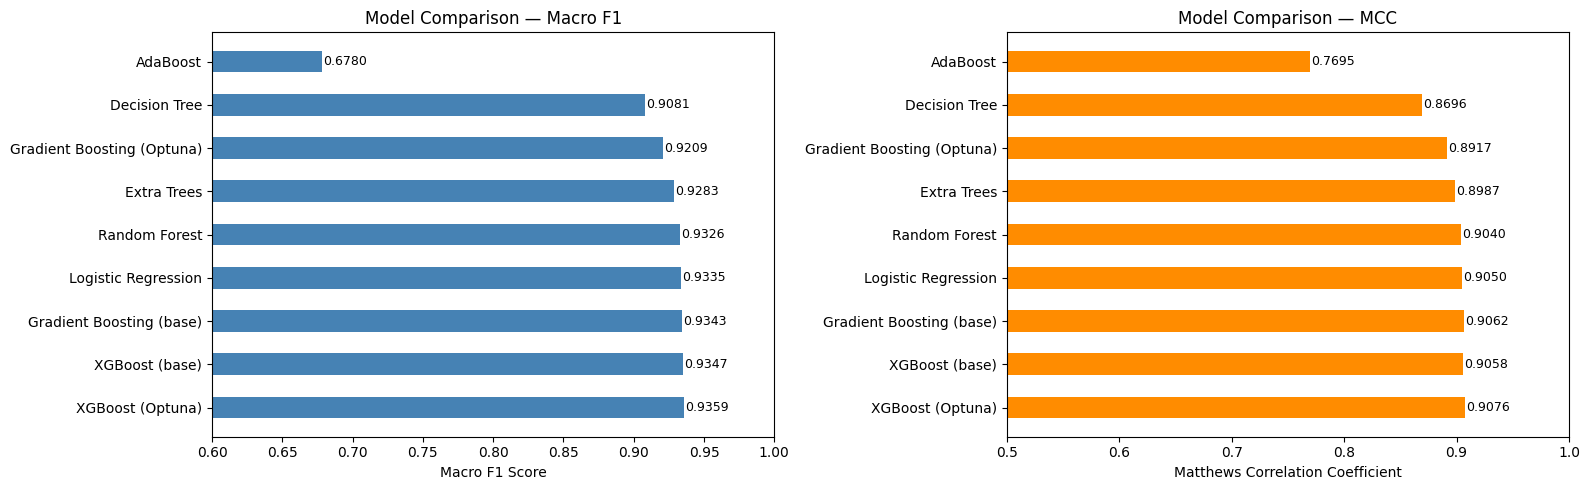

In [39]:
# Comparative visualization of model performance

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

models_labels = results_df["Model"].tolist()
x = np.arange(len(models_labels))

# Macro F1 plot
axes[0].barh(x, results_df["F1 (macro)"], color="steelblue", height=0.5)
axes[0].set_yticks(x)
axes[0].set_yticklabels(models_labels, fontsize=10)
axes[0].set_xlabel("Macro F1 Score")
axes[0].set_title("Model Comparison — Macro F1")
axes[0].set_xlim(0.6, 1.0)

# Add value labels
for i, v in enumerate(results_df["F1 (macro)"]):
    axes[0].text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=9)

# MCC plot
axes[1].barh(x, results_df["MCC"], color="darkorange", height=0.5)
axes[1].set_yticks(x)
axes[1].set_yticklabels(models_labels, fontsize=10)
axes[1].set_xlabel("Matthews Correlation Coefficient")
axes[1].set_title("Model Comparison — MCC")
axes[1].set_xlim(0.5, 1.0)

# Add value labels
for i, v in enumerate(results_df["MCC"]):
    axes[1].text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### Key Findings

1. **XGBoost and Gradient Boosting (Optuna)** achieved the best overall performance, confirming that boosting methods are well-suited for this dataset.

2. **AdaBoost** was the clear outlier with a significantly lower Macro F1. This is expected since AdaBoost is sensitive to noisy or overlapping classes, and performs best with very shallow trees (depth=1).

3. **Class BOMBAY (label 1)** was perfectly classified (F1 = 1.00) by virtually all models, reflecting its strong morphological separability despite being the smallest class.

4. **Hyperparameter tuning with Optuna** yielded only marginal gains over base models, indicating that default configurations were already near-optimal for this dataset. The MedianPruner successfully eliminated underperforming trials early.

5. **MCC and Macro F1 rankings are consistent**, validating Macro F1 as the primary evaluation metric for this multiclass imbalanced problem.

## **5. Lessons Learned**

### Key challenges and how we overcame them

**1. Computational cost of hyperparameter tuning:**
Gradient Boosting with Optuna was extremely slow, forcing us to reduce the number of trials to 5. To eliminate this, we prioritized tuning XGBoost instead, which achieves similar performance with much faster training times.

**2. Pruner not acting without trial.report():**
Although we added a MedianPruner to the Optuna study, we forgot to include `trial.report()` and `trial.should_prune()` inside the objective function. Without these functions, the pruner exists but never prunes any trial. Adding them allowed the pruner to cancel underperforming trials early, saving computation.

**3. Data leakage risk:**
Applying SMOTE before splitting into train/test sets would cause data leakage, as synthetic samples generated from the full dataset could leak test information into training. We avoided this by applying SMOTE exclusively on the training set after the split.

### Insights from Working with an Imbalanced Dataset

**1. Imbalance was moderate, not severe:**
The Dry Bean dataset has a 6.8:1 ratio between the largest (DERMASON, 2837) and smallest (BOMBAY, 418) classes. This level of imbalance is moderate, which explains why even baseline models like Logistic Regression performed well without any balancing technique.

**2. SMOTE did not significantly improve results:**
Contrary to what might be expected, SMOTE gave virtually the same performance as class_weight balancing. This suggests the classes are geometrically well-separated in feature space, and the models can already distinguish them without synthetic data generation.

**3. AdaBoost is sensitive to this type of problem:**
AdaBoost performed much worse than all other ensemble methods. This remarks that algorithm selection matters as much as preprocessing, a powerful ensemble method is not always the best choice depending on the dataset's characteristics.

**4. The best model is not always the most complex:**
Logistic Regression, a simple linear model, outperformed Random Forest on base configurations. This reinforces the importance of always establishing a strong baseline before doing any more complex models.